In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

In [2]:
df = pd.read_csv(
    "forcedphotometry_req00455934_lc.txt",
    sep=r"\s+",
    comment="#",
    engine="python"
)

df.columns = [c.strip().rstrip(",") for c in df.columns]

# 3. Rename columns to match expected names
df = df.rename(columns={"ccdid": "ccd"})
if "refFlux" in df.columns:
    df = df.rename(columns={"refFlux": "ref_flux"})

In [3]:
required_cols = [
    "jd",
    "forcediffimflux",
    "forcediffimfluxunc",
    "zpdiff",
    "filter",
    "field",
    "ccd",
    "qid"
]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

print("All required columns present ✅")


All required columns present ✅


Baseline correction complete ✅


/Users/gracedavis/WORK STUFF/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/gracedavis/WORK STUFF/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/gracedavis/WORK STUFF/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/gracedavis/WORK STUFF/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/gracedavis/WORK STUFF/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:8

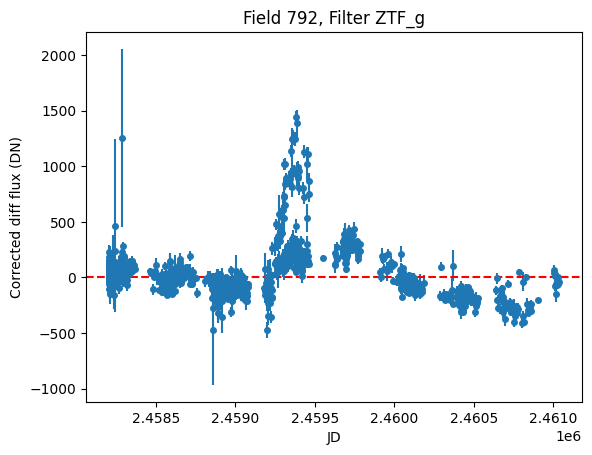

Saved baseline-corrected light curve ✅


In [4]:
df["baseline"] = np.nan
df["flux_corr"] = np.nan

# 6. Baseline correction function (ignores NaNs/infs)
def estimate_baseline(flux, sigma=3, maxiters=5):
    flux_clean = flux.replace([np.inf, -np.inf], np.nan).dropna()
    if len(flux_clean) == 0:
        return np.nan
    clipped = sigma_clip(flux_clean, sigma=sigma, maxiters=maxiters)
    return np.nanmedian(clipped)

# 7. Grouping columns
group_cols = ["field", "ccd", "qid", "filter"]

# 8. Apply baseline correction
JD_BASELINE_MIN = None  # optional: set JD before transient
JD_BASELINE_MAX = None  # optional: set JD after transient

for (field, ccd, qid, filt), g in df.groupby(group_cols):
    if len(g) < 30:
        continue  # skip groups with too few points

    # Optional JD window
    mask = np.ones(len(g), dtype=bool)
    if JD_BASELINE_MIN is not None:
        mask &= g["jd"] >= JD_BASELINE_MIN
    if JD_BASELINE_MAX is not None:
        mask &= g["jd"] <= JD_BASELINE_MAX

    baseline = estimate_baseline(g["forcediffimflux"][mask])

    idx = g.index
    df.loc[idx, "baseline"] = baseline
    df.loc[idx, "flux_corr"] = g["forcediffimflux"] - baseline

print("Baseline correction complete ✅")

# 9. Quick plot example for first group (safe)
example_group = next(iter(df.groupby(group_cols)))[1]

plt.errorbar(
    example_group["jd"],
    example_group["flux_corr"],
    yerr=example_group["forcediffimfluxunc"],
    fmt="o",
    ms=4
)

# safe access to field/filter
field_name = example_group.iloc[0]["field"]
filter_name = example_group.iloc[0]["filter"]

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("JD")
plt.ylabel("Corrected diff flux (DN)")
plt.title(f'Field {field_name}, Filter {filter_name}')
plt.show()

# 10. Convert to calibrated magnitudes
if "ref_flux" not in df.columns:
    # if ref_flux column does not exist, create as zeros
    df["ref_flux"] = 0.0

df["flux_total"] = df["ref_flux"] + df["flux_corr"]

det = df["flux_total"] > 0

df["mag"] = np.nan
df["mag_unc"] = np.nan

df.loc[det, "mag"] = df.loc[det, "zpdiff"] - 2.5 * np.log10(df.loc[det, "flux_total"])
df.loc[det, "mag_unc"] = 2.5 / np.log(10) * df.loc[det, "forcediffimfluxunc"] / df.loc[det, "flux_total"]

# 11. Upper limits for non-detections
NSIGMA = 5
nondet = df["flux_total"] <= 0
df["mag_lim"] = np.nan
df.loc[nondet, "mag_lim"] = df.loc[nondet, "zpdiff"] - 2.5 * np.log10(NSIGMA * df.loc[nondet, "forcediffimfluxunc"])

# 12. Save baseline-corrected table
df.to_csv("forcedphotometry_req00455934_lc_baseline_corrected.csv", index=False)
print("Saved baseline-corrected light curve ✅")

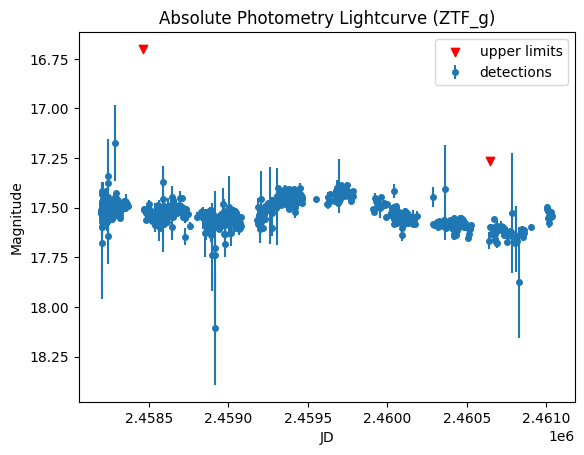

Brightest (min mag): 17.173
Faintest (max mag): 18.106
Difference (Δmag): 0.933


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters
SNT = 3  # detection threshold
SNU = 5  # upper limit threshold

# 2. Compute nearest reference flux and uncertainty
df["nearestrefmag"] = df["nearestrefmag"].fillna(0.0)
df["nearestrefmagunc"] = df["nearestrefmagunc"].fillna(0.0)

df["nearestrefflux"] = 10**(0.4 * (df["zpdiff"] - df["nearestrefmag"]))
df["nearestreffluxunc"] = df["nearestrefmagunc"] * df["nearestrefflux"] / 1.0857

# 3. Compute total flux and uncertainty
df["Fluxtot"] = df["forcediffimflux"] + df["nearestrefflux"]

# Anti-correlated uncertainties
df["Fluxunctot"] = np.sqrt(np.maximum(
    df["forcediffimfluxunc"]**2 - df["nearestreffluxunc"]**2, 0.0
))

# Fallback if subtraction fails
bad_unc_mask = df["Fluxunctot"] <= 0
df.loc[bad_unc_mask, "Fluxunctot"] = np.sqrt(
    df.loc[bad_unc_mask, "forcediffimfluxunc"]**2 +
    df.loc[bad_unc_mask, "nearestreffluxunc"]**2
)

# 4. Compute total S/N
df["SNRtot"] = df["Fluxtot"] / df["Fluxunctot"]

# 5. Compute magnitudes and upper limits
df["mag_abs"] = np.nan
df["mag_abs_unc"] = np.nan
df["mag_upperlim"] = np.nan

det_mask = df["SNRtot"] > SNT
non_det_mask = ~det_mask

# Detections
df.loc[det_mask, "mag_abs"] = (
    df.loc[det_mask, "zpdiff"] - 2.5 * np.log10(df.loc[det_mask, "Fluxtot"])
)
df.loc[det_mask, "mag_abs_unc"] = 1.0857 / df.loc[det_mask, "SNRtot"]

# Upper limits
df.loc[non_det_mask, "mag_upperlim"] = (
    df.loc[non_det_mask, "zpdiff"]
    - 2.5 * np.log10(SNU * df.loc[non_det_mask, "Fluxunctot"])
)

# 6. Plot for one filter
filt = "ZTF_g"  # change if needed
df_filt = df[df["filter"] == filt]

if len(df_filt) == 0:
    print(f"No data for filter {filt}")
else:
    plt.errorbar(
        df_filt["jd"],
        df_filt["mag_abs"],
        yerr=df_filt["mag_abs_unc"],
        fmt="o",
        ms=4,
        label="detections"
    )

    plt.scatter(
        df_filt["jd"],
        df_filt["mag_upperlim"],
        marker="v",
        color="red",
        label="upper limits"
    )

    plt.gca().invert_yaxis()
    plt.xlabel("JD")
    plt.ylabel("Magnitude")
    plt.title(f"Absolute Photometry Lightcurve ({filt})")
    plt.legend()
    plt.show()

    # 7. Compute magnitude difference (faintest - brightest)
    valid_mag = df_filt["mag_abs"].dropna()

    if len(valid_mag) == 0:
        print("No valid magnitude detections to compute difference.")
    else:
        brightest = valid_mag.min()   # lowest mag (brightest)
        faintest = valid_mag.max()    # highest mag (faintest)
        mag_diff = faintest - brightest

        print(f"Brightest (min mag): {brightest:.3f}")
        print(f"Faintest (max mag): {faintest:.3f}")
        print(f"Difference (Δmag): {mag_diff:.3f}")

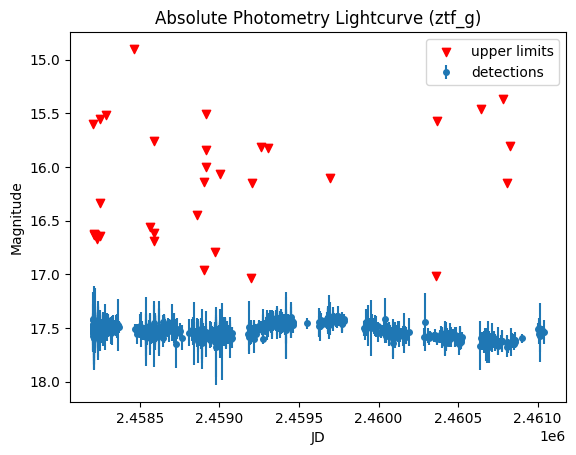

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters
SNT = 3  # detection threshold
SNU = 5  # upper limit threshold

# 2. Compute nearest reference flux and uncertainty
# Make sure nearestrefmag and nearestrefmagunc have no NaNs
df["nearestrefmag"] = df["nearestrefmag"].fillna(0.0)
df["nearestrefmagunc"] = df["nearestrefmagunc"].fillna(0.0)

df["nearestrefflux"] = 10**(0.4 * (df["zpdiff"] - df["nearestrefmag"]))
df["nearestreffluxunc"] = df["nearestrefmagunc"] * df["nearestrefflux"] / 1.0857

# 3. Compute total flux and uncertainty
df["Fluxtot"] = df["forcediffimflux"] + df["nearestrefflux"]

# Anti-correlated uncertainties (from the same reference image)
df["Fluxunctot"] = np.sqrt(np.maximum(df["forcediffimfluxunc"]**2 - df["nearestreffluxunc"]**2, 0.0))

# fallback: if the sqrt is <=0, add variances instead (conservative)
bad_unc_mask = df["Fluxunctot"] <= 0
df.loc[bad_unc_mask, "Fluxunctot"] = np.sqrt(df.loc[bad_unc_mask, "forcediffimfluxunc"]**2 +
                                              df.loc[bad_unc_mask, "nearestreffluxunc"]**2)

# 4. Compute total S/N
df["SNRtot"] = df["Fluxtot"] / df["Fluxunctot"]

# 5. Compute absolute magnitudes and upper limits
df["mag_abs"] = np.nan
df["mag_abs_unc"] = np.nan
df["mag_upperlim"] = np.nan

det_mask = df["SNRtot"] > SNT
non_det_mask = ~det_mask

# confident detections
df.loc[det_mask, "mag_abs"] = df.loc[det_mask, "zpdiff"] - 2.5 * np.log10(df.loc[det_mask, "Fluxtot"])
df.loc[det_mask, "mag_abs_unc"] = 1.0857 / df.loc[det_mask, "SNRtot"]

# upper limits
df.loc[non_det_mask, "mag_upperlim"] = df.loc[non_det_mask, "zpdiff"] - 2.5 * np.log10(SNU * df.loc[non_det_mask, "Fluxunctot"])

# 6. Plot example for one filter (use exact filter name from your table)
filt = "ztf_g"  # replace with 'ztf_r' or 'ztf_i' for other bands
df_filt = df[df["filter"] == filt]

if len(df_filt) == 0:
    print(f"No data for filter {filt}")
else:
    plt.errorbar(df_filt["jd"], df_filt["mag_abs"], yerr=df_filt["mag_abs_unc"], fmt="o", ms=4, label="detections")
    plt.scatter(df_filt["jd"], df_filt["mag_upperlim"], marker="v", color="red", label="upper limits")
    plt.gca().invert_yaxis()  # magnitudes: smaller = brighter
    plt.xlabel("JD")
    plt.ylabel("Magnitude")
    plt.title(f"Absolute Photometry Lightcurve ({filt})")
    plt.legend()
    plt.show()

Available filters: ['ZTF_r' 'ZTF_g' 'ZTF_i']


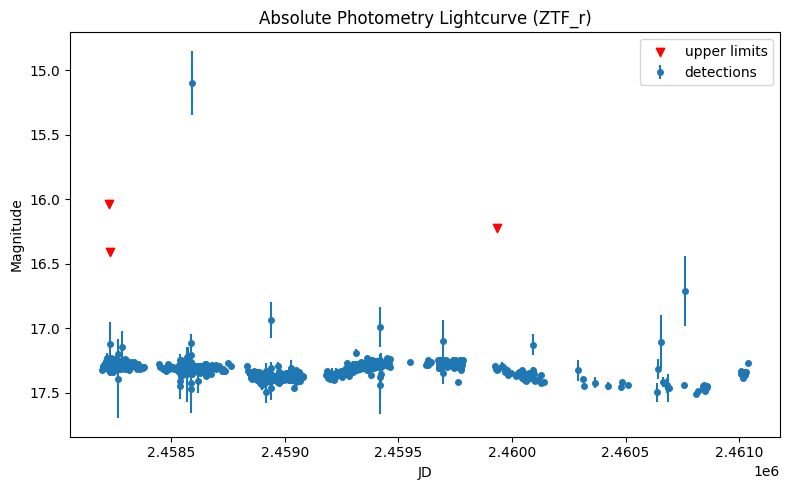

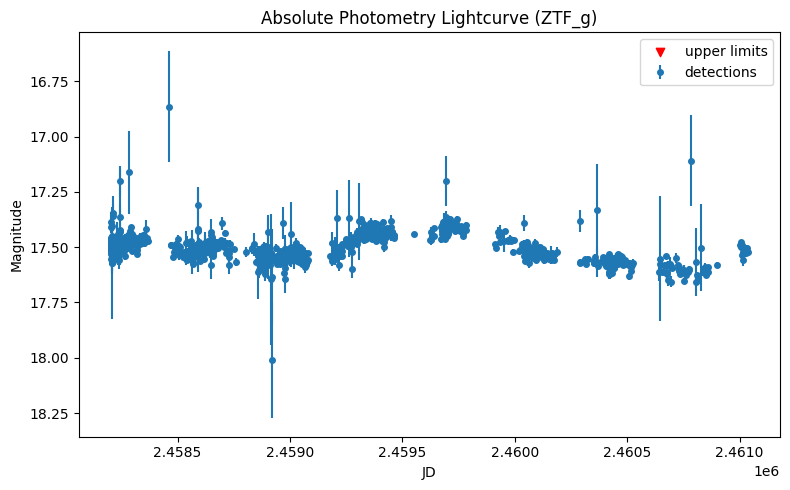

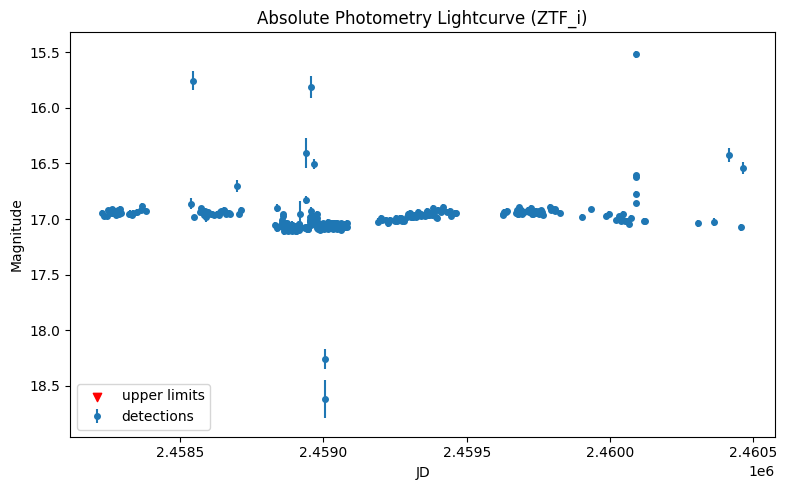

In [94]:
available_filters = df["filter"].unique()
print(f"Available filters: {available_filters}")

for filt in available_filters:
    df_filt = df[df["filter"] == filt]
    
    if len(df_filt) == 0:
        print(f"No data for filter {filt}")
        continue

    plt.figure(figsize=(8,5))
    
    # Plot detections
    det_mask = ~df_filt["mag_abs"].isna()
    plt.errorbar(
        df_filt.loc[det_mask, "jd"],
        df_filt.loc[det_mask, "mag_abs"],
        yerr=df_filt.loc[det_mask, "mag_abs_unc"],
        fmt="o",
        ms=4,
        label="detections"
    )
    
    # Plot upper limits
    upper_mask = ~df_filt["mag_upperlim"].isna()
    plt.scatter(
        df_filt.loc[upper_mask, "jd"],
        df_filt.loc[upper_mask, "mag_upperlim"],
        marker="v",
        color="red",
        label="upper limits"
    )
    
    plt.gca().invert_yaxis()  # magnitudes: smaller = brighter
    plt.xlabel("JD")
    plt.ylabel("Magnitude")
    plt.title(f"Absolute Photometry Lightcurve ({filt})")
    plt.legend()
    plt.tight_layout()
    plt.show()